# S6E9: GPU-Accelerated Random Forest (RAPIDS cuML)
Random Forests are heavily decorrelated from Gradient Boosting. Training a Random Forest on 678,000 rows usually takes hours, but using Kaggle's GPU and NVIDIA RAPIDS cuML, we can train it in seconds.
If this provides a great blending anchor, please upvote!

In [1]:
import gc
import pandas as pd
import numpy as np
import cupy as cp

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import cuml
from cuml.ensemble import RandomForestClassifier

print(f"RAPIDS cuML version: {cuml.__version__}")

RAPIDS cuML version: 26.02.000


In [2]:
# 1. Load Data
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/test.csv')
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv')
orig = pd.read_csv('/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv')

orig = orig.drop(columns=['Buyer_ID'], errors='ignore')
orig = orig.dropna()
orig['id'] = -1
orig['Will_Buy_EV'] = orig['Will_Buy_EV'].map({'Yes': 1, 'No': 0})
train['Will_Buy_EV'] = train['Will_Buy_EV'].map({'Yes': 1, 'No': 0})

train = pd.concat([train, orig], axis=0).reset_index(drop=True)
print(f"Combined Train size: {train.shape}")


Combined Train size: (678131, 15)


In [3]:
# 2. Feature Engineering
def feature_engineering(df1):
    df = df1.copy()
    df['Subsidy_Available_Num'] = (df['Subsidy_Available'] == 'Yes').astype(int)
    df['Home_Charging_Num'] = (df['Home_Charging_Possible'] == 'Yes').astype(int)
    
    anxiety_map = {'Low': 0, 'Medium': 1, 'High': 2}
    if 'Range_Anxiety_Level' in df.columns:
        df['Anxiety_Score'] = df['Range_Anxiety_Level'].map(anxiety_map)
        
    df['Sub_x_Env'] = df['Subsidy_Available_Num'] * df['Environmental_Concern_Level']
    df['Sub_x_Home'] = df['Subsidy_Available_Num'] * df['Home_Charging_Num']
    df['Income_Per_Age'] = df['Annual_Income_USD'] / (df['Age'] + 1)
    return df

train_fe = feature_engineering(train)
test_fe = feature_engineering(test)

# 3. Preprocessing (cuML requires float32 DataFrames)
cat_cols = ['Gender', 'City_Type', 'Current_Car_Type', 'Subsidy_Available', 'Home_Charging_Possible', 'Range_Anxiety_Level']
num_cols = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 
            'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 
            'Environmental_Concern_Level', 'Sub_x_Env', 'Sub_x_Home', 'Income_Per_Age', 'Anxiety_Score']

features = cat_cols + num_cols

for c in num_cols:
    train_fe[c] = train_fe[c].fillna(train_fe[c].median())
    test_fe[c]  = test_fe[c].fillna(train_fe[c].median())

for c in cat_cols:
    le = LabelEncoder()
    train_fe[c] = le.fit_transform(train_fe[c].astype(str))
    test_fe[c]  = le.transform(test_fe[c].astype(str))

# cuML strictly prefers float32
X = train_fe[features].astype('float32')
y = train_fe['Will_Buy_EV'].astype('int32')
X_test = test_fe[features].astype('float32')

X

,Gender,City_Type,Current_Car_Type,Subsidy_Available,Home_Charging_Possible,Range_Anxiety_Level,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Sub_x_Env,Sub_x_Home,Income_Per_Age,Anxiety_Score
0,1.0,1.0,2.0,0.0,1.0,1.0,66.0,92887.0,23.400000,2.0,3.0,7.0,1.0,0.0,0.0,1386.373169,0.0
1,1.0,0.0,1.0,0.0,1.0,1.0,38.0,30000.0,5.000000,1.0,2.0,2.0,4.0,0.0,0.0,769.230774,0.0
2,0.0,2.0,2.0,1.0,0.0,1.0,26.0,94389.0,36.799999,1.0,8.0,15.0,5.0,5.0,0.0,3495.888916,0.0
3,1.0,1.0,0.0,0.0,1.0,1.0,66.0,73580.0,23.700001,2.0,6.0,9.0,3.0,0.0,0.0,1098.208984,0.0
4,1.0,1.0,0.0,0.0,1.0,1.0,54.0,57898.0,50.799999,1.0,2.0,3.0,3.0,0.0,0.0,1052.690918,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678126,1.0,2.0,2.0,1.0,0.0,2.0,50.0,61279.0,71.400002,1.0,8.0,3.0,3.0,3.0,0.0,1201.549072,1.0
678127,1.0,2.0,0.0,0.0,0.0,1.0,34.0,108208.0,48.000000,2.0,9.0,7.0,5.0,0.0,0.0,3091.657227,0.0
678128,0.0,2.0,2.0,1.0,0.0,1.0,60.0,97743.0,9.000000,2.0,10.0,3.0,5.0,5.0,0.0,1602.344238,0.0
678129,0.0,2.0,1.0,1.0,1.0,1.0,31.0,103628.0,81.800003,2.0,10.0,10.0,1.0,1.0,1.0,3238.375000,0.0


In [4]:
# 4. 10-Fold CV with cuML Random Forest
FOLDS = 10

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(train))
test_preds = np.zeros(len(test))
feat_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- FOLD {fold+1}/{FOLDS} ---")
    
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    # GPU Accelerated Random Forest
    # We use 500 trees and depth 15 (Random Forest works best when deep)
    model = RandomForestClassifier(
        n_estimators=1000,
        max_depth=12,
        max_features=0.6,
        min_samples_leaf=150,
        random_state=42, #+ fold
    )
    
    model.fit(X_train, y_train)

    feat_importances.append(model.feature_importances_)
    
    # Predict probabilities (cuML returns [p(0), p(1)])
    val_preds = model.predict_proba(X_val)[1]
    fold_test_preds = model.predict_proba(X_test)[1]
    
    # Move back from cupy to numpy if needed
    if isinstance(val_preds, cp.ndarray):
        val_preds = val_preds.get()
        fold_test_preds = fold_test_preds.get()

    oof_preds[val_idx] = val_preds
    test_preds += fold_test_preds / FOLDS
    
    val_auc = roc_auc_score(y_val, val_preds)
    print(f"Fold {fold+1} AUC: {val_auc:.6f}")

oof_auc = roc_auc_score(y, oof_preds)
print(f"\nFINAL OOF AUC cuML RANDOM FOREST: {oof_auc:.6f}")

# sub = test[['id']].copy()
# sub['Will_Buy_EV'] = test_preds
# sub.to_csv('submission.csv', index=False)
# print("submission.csv successfully generated!")


--- FOLD 1/10 ---
Fold 1 AUC: 0.939165

--- FOLD 2/10 ---
Fold 2 AUC: 0.937865

--- FOLD 3/10 ---
Fold 3 AUC: 0.938892

--- FOLD 4/10 ---
Fold 4 AUC: 0.940974

--- FOLD 5/10 ---
Fold 5 AUC: 0.939436

--- FOLD 6/10 ---
Fold 6 AUC: 0.939102

--- FOLD 7/10 ---
Fold 7 AUC: 0.938530

--- FOLD 8/10 ---
Fold 8 AUC: 0.939894

--- FOLD 9/10 ---
Fold 9 AUC: 0.938841

--- FOLD 10/10 ---
Fold 10 AUC: 0.939433

FINAL OOF AUC cuML RANDOM FOREST: 0.939195


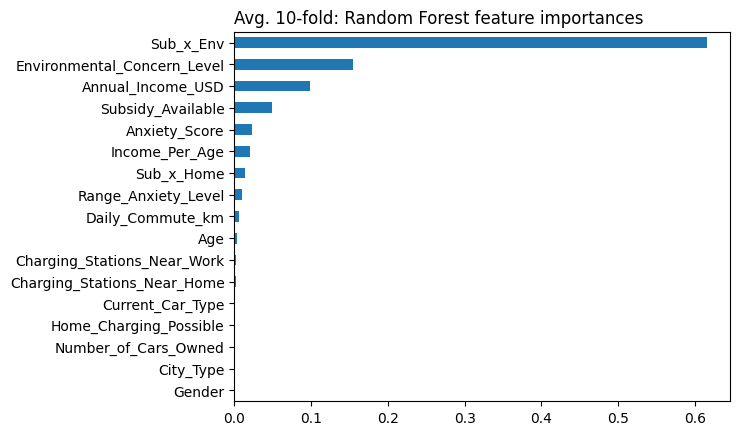

In [5]:
imp_df = pd.Series(np.mean(feat_importances, axis=0), index=X.columns).sort_values()
imp_df.plot.barh()
plt.title(f"Avg. {FOLDS}-fold: Random Forest feature importances", loc='left')
plt.show()

In [6]:
MODEL_NAME = "cuml_RANDOMFOREST"

# Save OOF Predictions (for ensembling meta-model)
# oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{MODEL_NAME}_{oof_auc:.6f}.npy", oof_preds)
print(f"💾 Saved 'oof_{MODEL_NAME}_{oof_auc:.6f}.npy'")

# Save Raw Test Predictions (for ensembling)
# test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{MODEL_NAME}_{oof_auc:.6f}.npy", test_preds)
print(f"💾 Saved 'test_{MODEL_NAME}_{oof_auc:.6f}.npy'")

# Save Kaggle Submission (Averaged Test Predictions)
submission['Will_Buy_EV'] = test_preds
submission.to_csv(f'submission_{MODEL_NAME}_{oof_auc:.6f}.csv', index=False)
print(f"💾 Saved 'submission_{MODEL_NAME}_{oof_auc:.6f}.csv'")

submission

💾 Saved 'oof_cuml_RANDOMFOREST_0.939195.npy'
💾 Saved 'test_cuml_RANDOMFOREST_0.939195.npy'
💾 Saved 'submission_cuml_RANDOMFOREST_0.939195.csv'


,id,Will_Buy_EV
0,668665,0.009450
1,668666,0.025048
2,668667,0.002601
3,668668,0.001605
4,668669,0.015811
...,...,...
286566,955231,0.000175
286567,955232,0.183679
286568,955233,0.004027
286569,955234,0.000838


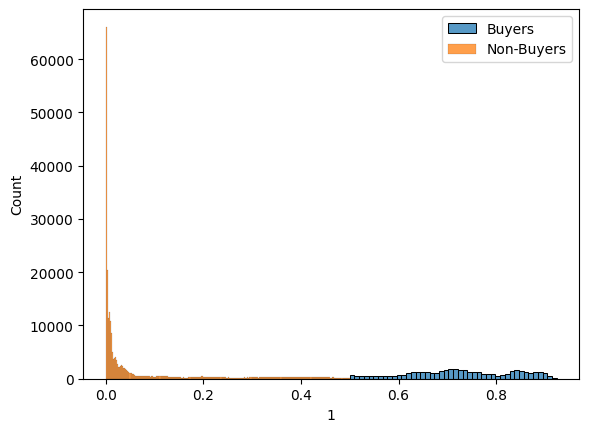

In [7]:
buyers = test_preds[test_preds >= 0.5]
non_buyers = test_preds[test_preds < 0.5]

sns.histplot(buyers, label="Buyers")
sns.histplot(non_buyers, label="Non-Buyers")
plt.legend()
plt.show()

In [8]:
# !rm -r /kaggle/working/